# 三季擴充（2021–2023）：合併榜單與跨季持續性

把管線套到 2021、2022、2023 三個例行賽（每季各自 fit 基準 GAM）。三季共 106 萬顆判定球，剔除極端座標後 104 萬顆進入建模。
三季讓我們能：(1) 合併出樣本更大、更穩的 framing 榜單；(2) 完整檢視技術的跨季持續性
（連續年 vs 隔一年）。

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from models.reliability import pooled_leaderboard, pairwise_year_correlations, season_rate_leaderboard
from models.framing_runs import add_names

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = ['PingFang TC', 'Arial Unicode MS', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

seasons = {y: pl.read_parquet(f'../data/processed/statcast_{y}_baseline.parquet') for y in (2021, 2022, 2023)}
for y, d in seasons.items(): print(f'{y}: {d.height:,} 顆')
print('三季合計:', sum(d.height for d in seasons.values()), '顆')

2021: 345,496 顆
2022: 343,865 顆
2023: 351,094 顆
三季合計: 1040455 顆


## 三季合併 framing 榜單

每季殘差相對於該季自己的基準，跨季加總（門檻：三季合計 ≥ 3000 顆判定球）。
樣本變大，估計更能反映真實技術。

In [2]:
pooled = add_names(pooled_leaderboard(seasons, min_pitches=3000))
show = ['name','called_pitches','extra_strikes','framing_runs','framing_runs_per_1000']
print(f'合格捕手 n = {pooled.height}')
print('=== 三季合併前 12 ===')
print(pooled.head(12).select(show))
print('=== 後 6 ===')
print(pooled.sort('framing_runs').head(6).select(show))

合格捕手 n = 94
=== 三季合併前 12 ===
shape: (12, 5)
┌────────────────────┬────────────────┬───────────────┬──────────────┬───────────────────────┐
│ name               ┆ called_pitches ┆ extra_strikes ┆ framing_runs ┆ framing_runs_per_1000 │
│ ---                ┆ ---            ┆ ---           ┆ ---          ┆ ---                   │
│ str                ┆ u32            ┆ f64           ┆ f64          ┆ f64                   │
╞════════════════════╪════════════════╪═══════════════╪══════════════╪═══════════════════════╡
│ Trevino, Jose      ┆ 15799          ┆ 320.167597    ┆ 40.02095     ┆ 2.533132              │
│ Heim, Jonah        ┆ 20171          ┆ 306.260167    ┆ 38.282521    ┆ 1.897899              │
│ Hedges, Austin     ┆ 16629          ┆ 178.047889    ┆ 22.255986    ┆ 1.338384              │
│ Raleigh, Cal       ┆ 17356          ┆ 172.127037    ┆ 21.51588     ┆ 1.23968               │
│ Murphy, Sean       ┆ 22284          ┆ 150.07632     ┆ 18.75954     ┆ 0.841839              │
│ …   

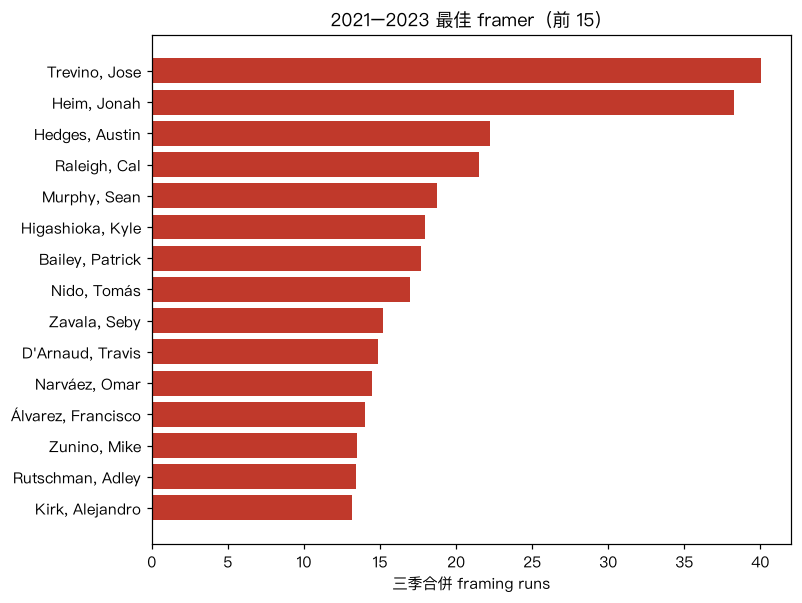

In [3]:
top = pooled.head(15).sort('framing_runs')
fig, ax = plt.subplots(figsize=(7.5, 6))
colors = ['#c0392b' if v>0 else '#2c7fb8' for v in top['framing_runs']]
ax.barh(top['name'], top['framing_runs'], color=colors)
ax.set_xlabel('三季合併 framing runs'); ax.set_title('2021–2023 最佳 framer（前 15）')
ax.axvline(0, color='grey', lw=0.6)
fig.savefig('../figures/pooled_leaderboard_2021_2023.png', bbox_inches='tight'); plt.show()

## 跨季持續性：兩兩相關矩陣

三季 framing 率的兩兩 Pearson 相關。若對角線外仍高，代表技術跨季穩定；
隔一年（2021↔2023）會低於連續年，反映技術隨時間漂移。

相關矩陣:
  2021 1.000 0.608 0.320
  2022 0.608 1.000 0.599
  2023 0.320 0.599 1.000


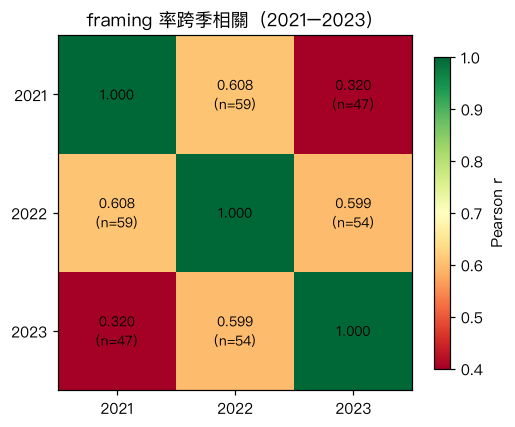

In [4]:
years, R, N = pairwise_year_correlations(seasons, min_pitches=1000)
print('相關矩陣:')
for i,ya in enumerate(years):
    print(' ', ya, ' '.join(f'{R[i,j]:.3f}' for j in range(len(years))))

fig, ax = plt.subplots(figsize=(5.2,4.6))
im = ax.imshow(R, cmap='RdYlGn', vmin=0.4, vmax=1.0)
ax.set_xticks(range(len(years))); ax.set_xticklabels(years)
ax.set_yticks(range(len(years))); ax.set_yticklabels(years)
for i in range(len(years)):
    for j in range(len(years)):
        txt = f'{R[i,j]:.3f}' + ('' if i==j else f'\n(n={N[i,j]})')
        ax.text(j, i, txt, ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, label='Pearson r', shrink=0.8)
ax.set_title('framing 率跨季相關（2021–2023）')
fig.savefig('../figures/persistence_matrix_2021_2023.png', bbox_inches='tight'); plt.show()

In [5]:
# 連續年 vs 隔一年
consec = np.mean([R[0,1], R[1,2]])
gap = R[0,2]
print(f'連續年平均 r = {consec:.3f}（2021→2022, 2022→2023）')
print(f'隔一年   r = {gap:.3f}（2021→2023）')
print('隔一年略低 → framing 技術跨季持續但隨時間緩慢衰減，符合預期。')

連續年平均 r = 0.603（2021→2022, 2022→2023）
隔一年   r = 0.320（2021→2023）
隔一年略低 → framing 技術跨季持續但隨時間緩慢衰減，符合預期。


## 名將三季軌跡

取三季合併榜前段與後段的代表捕手，看他們逐年的 framing 率——穩定者三季都在同一側。

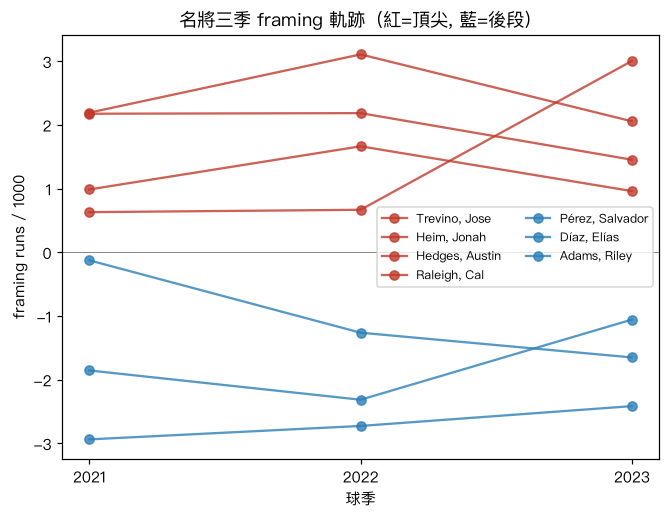

In [6]:
rates = {y: season_rate_leaderboard(d, 1000).select('mlbam_id', pl.col('rate').alias(str(y))) for y,d in seasons.items()}
traj = rates[2021].join(rates[2022],on='mlbam_id',how='inner').join(rates[2023],on='mlbam_id',how='inner')
traj = add_names(traj.rename({'2021':'r21','2022':'r22','2023':'r23'}))
pick = pooled.filter(pl.col('mlbam_id').is_in(traj['mlbam_id'].to_list())).sort('framing_runs',descending=True)
names_top = pick.head(4)['name'].to_list(); names_bot = pick.sort('framing_runs').head(3)['name'].to_list()

fig, ax = plt.subplots(figsize=(7,5))
for nm in names_top + names_bot:
    row = traj.filter(pl.col('name')==nm)
    if row.height==0: continue
    ys = [row['r21'][0], row['r22'][0], row['r23'][0]]
    color = '#c0392b' if nm in names_top else '#2c7fb8'
    ax.plot([2021,2022,2023], ys, 'o-', color=color, alpha=0.8, label=nm)
ax.axhline(0, color='grey', lw=0.6)
ax.set_xticks([2021,2022,2023]); ax.set_xlabel('球季'); ax.set_ylabel('framing runs / 1000')
ax.set_title('名將三季 framing 軌跡（紅=頂尖, 藍=後段）'); ax.legend(fontsize=8, ncol=2)
fig.savefig('../figures/catcher_trajectories_2021_2023.png', bbox_inches='tight'); plt.show()

## 三季合併階層模型

把週 6–7 的交叉隨機效應模型跑在**三季合併**的 104 萬顆上（見 `models/hierarchical.py` 的
`fit_and_cache_multi`）。每季用自己的基準 GAM（logit_base 已吸收各季好球帶差異），
捕手/主審/投手效應**跨三季共享**——同一位捕手三季只得到一個 pooled、收縮、控制混淆後的估計。

In [7]:
from models.hierarchical import load_cached
eff3, hier3, meta3 = load_cached('2021_2023')
print('n =', f"{meta3['n']:,}", '| β1(logit_base) =', round(meta3['slope'],3))
print('τ (三季):', {k: round(v,3) for k,v in meta3['tau'].items()})

h3 = add_names(hier3).filter(pl.col('called_pitches')>=3000)
print('\n=== 三季階層版前 10 ===')
print(h3.sort('framing_runs_model',descending=True).head(10).select(['name','called_pitches','catcher_effect','framing_runs_model']))
print('\n=== 後 5 ===')
print(h3.sort('framing_runs_model').head(5).select(['name','called_pitches','framing_runs_model']))

n = 1,040,455 | β1(logit_base) = 1.026
τ (三季): {'catcher': 0.184, 'umpire': 0.192, 'pitcher': 0.185}

=== 三季階層版前 10 ===
shape: (10, 4)
┌──────────────────┬────────────────┬────────────────┬────────────────────┐
│ name             ┆ called_pitches ┆ catcher_effect ┆ framing_runs_model │
│ ---              ┆ ---            ┆ ---            ┆ ---                │
│ str              ┆ u32            ┆ f64            ┆ f64                │
╞══════════════════╪════════════════╪════════════════╪════════════════════╡
│ Trevino, Jose    ┆ 15799          ┆ 0.397725       ┆ 40.093041          │
│ Heim, Jonah      ┆ 20171          ┆ 0.291572       ┆ 37.435373          │
│ Hedges, Austin   ┆ 16629          ┆ 0.283804       ┆ 30.789432          │
│ Raleigh, Cal     ┆ 17356          ┆ 0.248749       ┆ 27.285269          │
│ Murphy, Sean     ┆ 22284          ┆ 0.188286       ┆ 26.818971          │
│ Rutschman, Adley ┆ 13161          ┆ 0.255725       ┆ 21.233264          │
│ D'Arnaud, Travis ┆ 14915   

### 合併簡單版 vs 三季階層版
同一批捕手，比較「合併簡單版 framing runs」與「三季階層版」——
階層版控制主審/投手且收縮，極端值被適度拉回。

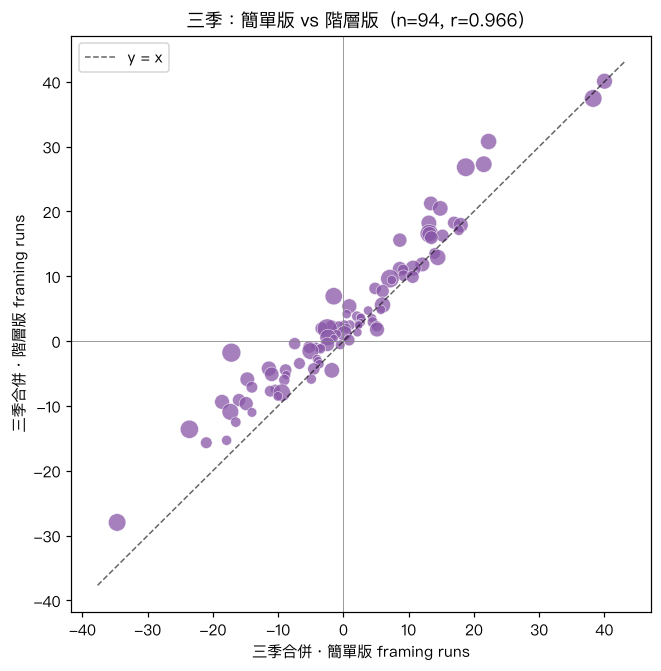

In [8]:
cmp3 = pooled.select(['mlbam_id','name','called_pitches','framing_runs']).join(
    hier3.select(['mlbam_id','framing_runs_model']), on='mlbam_id', how='inner')
x = cmp3['framing_runs'].to_numpy(); y = cmp3['framing_runs_model'].to_numpy()
from scipy.stats import pearsonr
pr,_ = pearsonr(x,y)
fig, ax = plt.subplots(figsize=(6.8,6.8))
lim=[min(x.min(),y.min())-3, max(x.max(),y.max())+3]
ax.plot(lim,lim,'k--',lw=1,alpha=0.6,label='y = x')
sizes = 10 + (cmp3['called_pitches'].to_numpy()/cmp3['called_pitches'].max())*160
ax.scatter(x,y,s=sizes,alpha=0.75,color='#8856a7',edgecolor='white',linewidth=0.4)
ax.axhline(0,color='grey',lw=0.5); ax.axvline(0,color='grey',lw=0.5)
ax.set_xlabel('三季合併・簡單版 framing runs'); ax.set_ylabel('三季合併・階層版 framing runs')
ax.set_title(f'三季：簡單版 vs 階層版（n={cmp3.height}, r={pr:.3f}）'); ax.legend(loc='upper left')
fig.savefig('../figures/pooled_simple_vs_hier_2021_2023.png', bbox_inches='tight'); plt.show()

## 觀察

- 三季合併（104 萬列）給出樣本更大、更穩的 framing 榜單，頂尖 framer 跨季一致。
- 跨季相關矩陣：連續年平均 0.603、隔一年 0.320。後者很接近單純 AR(1) 衰減的預測（0.603² = 0.364），所以 framing 比較像每年微幅漂移的技術，而不是固定不變的特質。
- 名將軌跡圖：頂尖 framer 三季都在正值側、後段班都在負值側，肉眼即見持續性。
- **三季合併階層模型**在 104 萬顆上同時控制主審/投手並收縮，給出最嚴謹的單一捕手估計；
  其排序與合併簡單版高度一致，但極端值被適度拉回（控制混淆 + shrinkage）。
- 這與週 8 的 split-half（同季 R≈0.90）互補：同季高度可重現、跨季顯著持續，
  共同確立 framing 是**真實、穩定、可預測**的技術。